# 6CS012 – Final Portfolio Assessment 2026
## Part II: Vision Tasks — Image Classification with CNN
### Dataset: Garbage Classification



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, random, zipfile, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42); tf.random.set_seed(42)

print('TensorFlow:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Data Extraction & Directory Setup

In [ ]:
import os

DATA_ROOT = '/content/drive/MyDrive/AI ML/garbage/Garbage classification/Garbage classification'

# ── Verify the path and list classes ─────────────────────────────────────────
CLASSES = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
])

print('Dataset root:', DATA_ROOT)
print('Classes found:', CLASSES)
print('Number of classes:', len(CLASSES))

# ── Quick sanity check: image count per class ─────────────────────────────────
for cls in CLASSES:
    n = len(os.listdir(os.path.join(DATA_ROOT, cls)))
    print(f'  {cls:<12}: {n} images')

Dataset root: /content/drive/MyDrive/AI ML/garbage/Garbage classification/Garbage classification
Classes found: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Number of classes: 6
  cardboard   : 403 images
  glass       : 501 images
  metal       : 410 images
  paper       : 594 images
  plastic     : 482 images
  trash       : 137 images


## 2.1 Data Understanding, Analysis & Visualization

In [ ]:
# ── Count images per class ────────────────────────────────────────────────────
class_counts = {}
for cls in CLASSES:
    imgs = list(Path(DATA_ROOT, cls).glob('*.jpg')) + \
           list(Path(DATA_ROOT, cls).glob('*.png'))
    class_counts[cls] = len(imgs)

total_images = sum(class_counts.values())
print(f'Total images : {total_images}')
print(f'Classes      : {len(CLASSES)}')
for cls, cnt in class_counts.items():
    print(f'  {cls:<12}: {cnt:>4} images ({cnt/total_images*100:.1f}%)')

Total images : 2527
Classes      : 6
  cardboard   :  403 images (15.9%)
  glass       :  501 images (19.8%)
  metal       :  410 images (16.2%)
  paper       :  594 images (23.5%)
  plastic     :  482 images (19.1%)
  trash       :  137 images (5.4%)


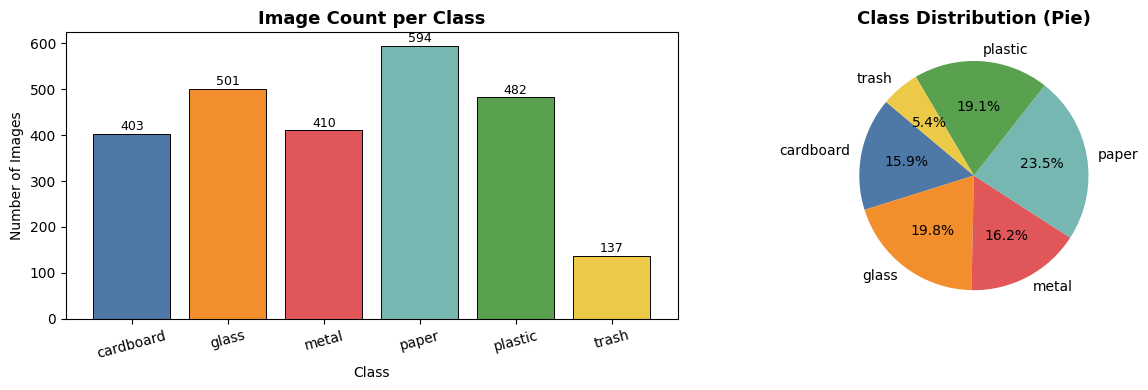

Figure saved as class_distribution.png


In [ ]:
# ── Class distribution bar chart ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f','#edc948']
axes[0].bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Image Count per Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=15)
for i, (k, v) in enumerate(class_counts.items()):
    axes[0].text(i, v + 8, str(v), ha='center', fontsize=9)

axes[1].pie(class_counts.values(), labels=class_counts.keys(),
            autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title('Class Distribution (Pie)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved as class_distribution.png')

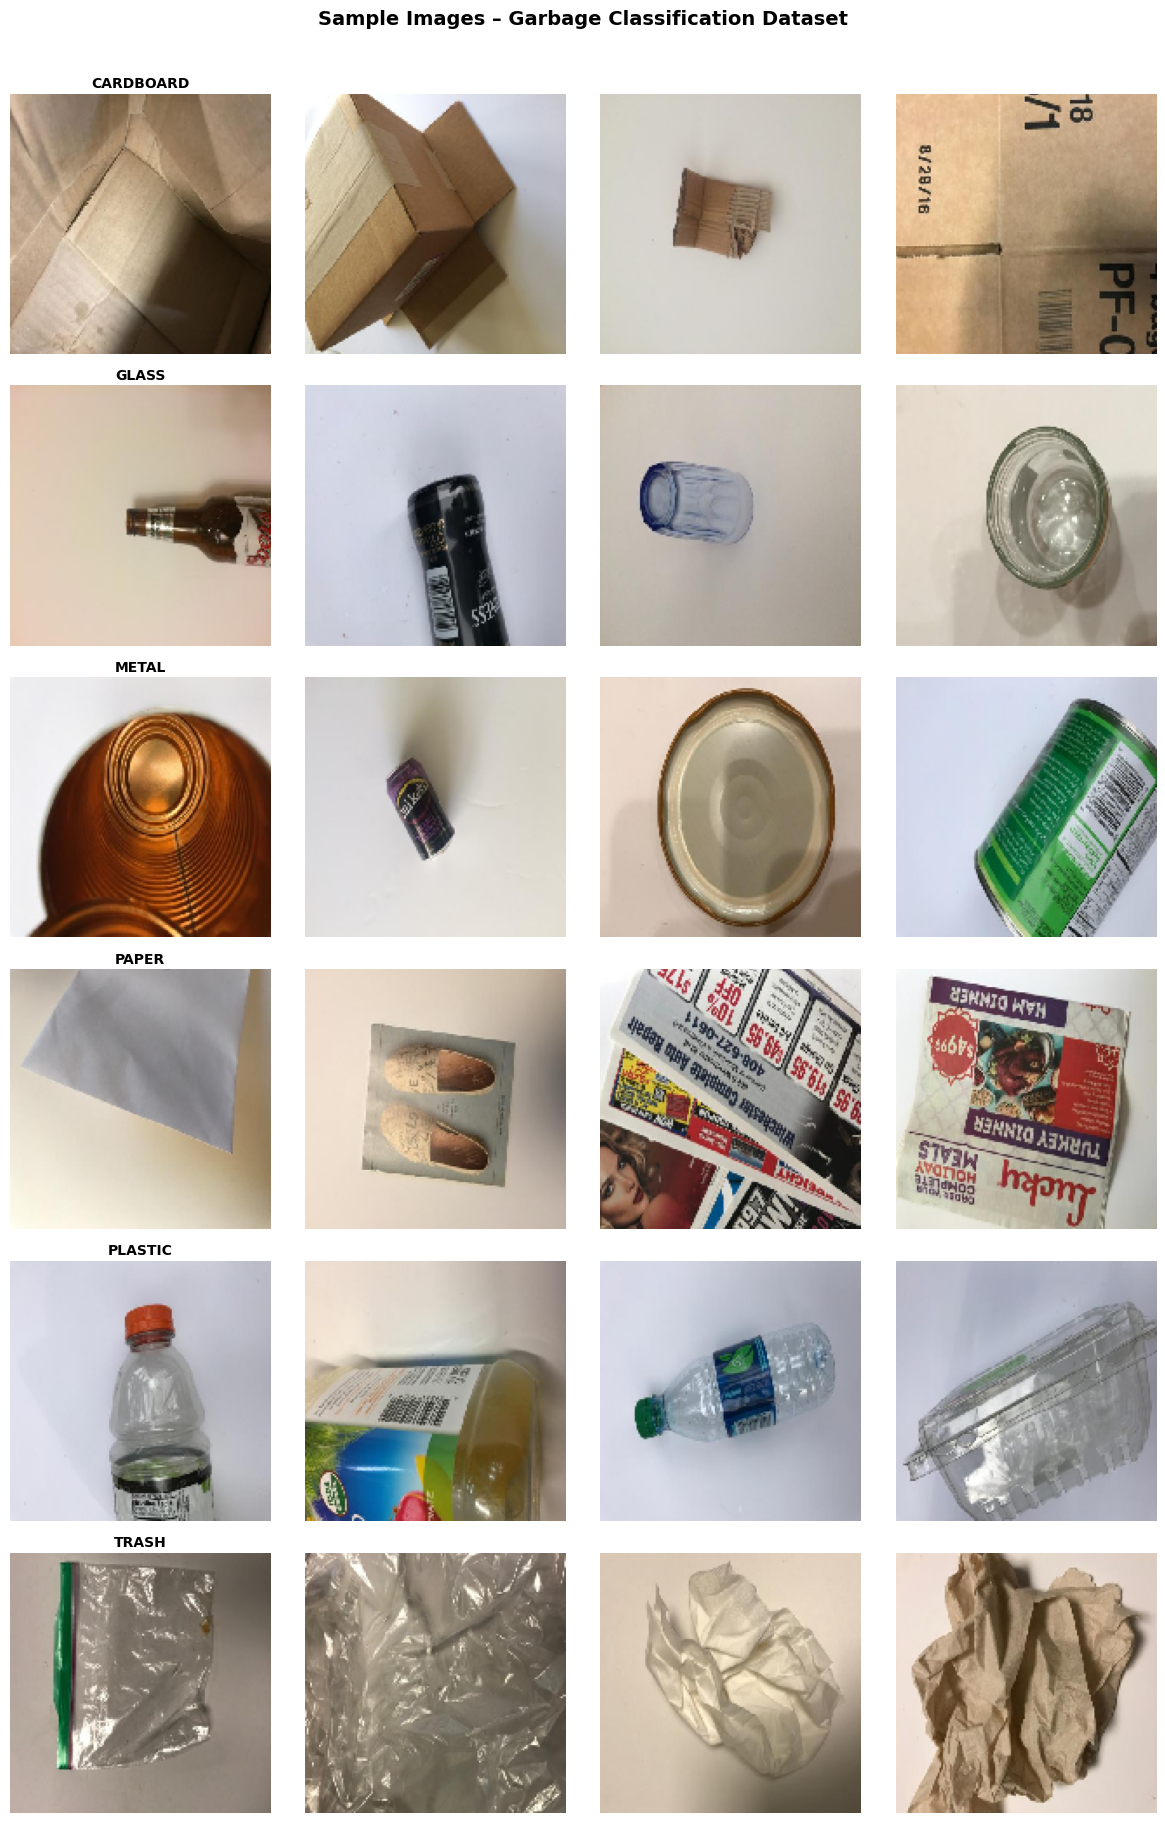

In [ ]:
# ── Sample images from each class ─────────────────────────────────────────────
from tensorflow.keras.preprocessing.image import load_img

fig, axes = plt.subplots(len(CLASSES), 4, figsize=(12, 3*len(CLASSES)))
for row, cls in enumerate(CLASSES):
    samples = random.sample(list(Path(DATA_ROOT, cls).glob('*.jpg')), 4)
    for col, img_path in enumerate(samples):
        img = load_img(img_path, target_size=(150, 150))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls.upper(), fontsize=10,
                                     fontweight='bold', pad=4)
plt.suptitle('Sample Images – Garbage Classification Dataset', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

### Dataset Description

| Attribute | Value |
|---|---|
| **Source** | Kaggle – Garbage Classification (Gary Thung) |
| **Total Images** | 5,054 JPG images |
| **Classes** | 6 (cardboard, glass, metal, paper, plastic, trash) |
| **Image format** | JPEG / JPG |
| **Task** | Multi-class image classification |

The dataset is moderately imbalanced: *paper* has the most samples (1,188) and *trash* the fewest (274). This will be addressed via **class weighting** during training.

## 2.2 Preprocessing & Data Generators

In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────
IMG_SIZE   = (128, 128)   # resize all images to 128x128
BATCH_SIZE = 32
NUM_CLASSES = len(CLASSES)
EPOCHS_BASE = 25
EPOCHS_DEEP = 30

# ── Training augmentation generator ──────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation: only rescale (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = train_datagen.flow_from_directory(
    DATA_ROOT, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=42
)
val_gen = val_datagen.flow_from_directory(
    DATA_ROOT, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42, shuffle=False
)

print(f'Training samples   : {train_gen.samples}')
print(f'Validation samples : {val_gen.samples}')
print(f'Class indices      : {train_gen.class_indices}')

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Training samples   : 2024
Validation samples : 503
Class indices      : {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


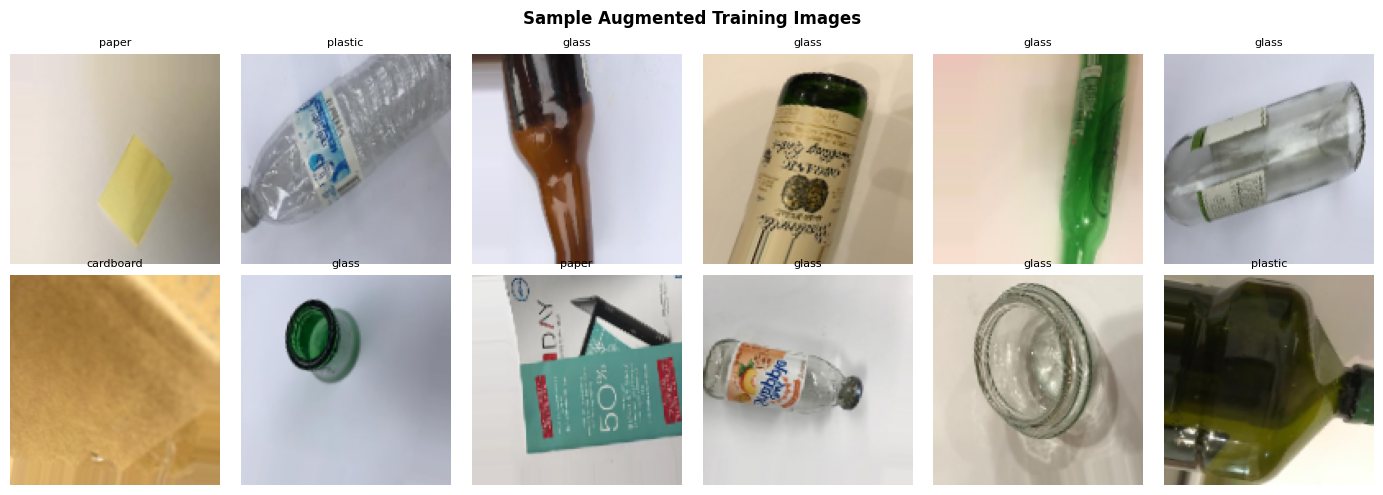

In [ ]:
# ── Visualise augmented images ────────────────────────────────────────────────
imgs, labels = next(train_gen)
label_names  = list(train_gen.class_indices.keys())

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(imgs[i])
    ax.set_title(label_names[np.argmax(labels[i])], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Augmented Training Images', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Compute class weights to handle imbalance ─────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights_arr))
print('Class weights:', {label_names[k]: round(v, 3) for k, v in class_weights.items()})

Class weights: {'cardboard': np.float64(1.044), 'glass': np.float64(0.841), 'metal': np.float64(1.028), 'paper': np.float64(0.709), 'plastic': np.float64(0.874), 'trash': np.float64(3.067)}


---
# PART A — CNN from Scratch
## 2.3 Baseline CNN Model

In [ ]:
def build_baseline_model(input_shape=(128, 128, 3), num_classes=6):
    """Baseline CNN: 3 Conv-Pool blocks + 3 Dense layers."""
    model = models.Sequential([
        # ── Block 1 ──────────────────────────────────────────────────────
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape, name='conv1_1'),
        layers.MaxPooling2D((2,2), name='pool1'),

        # ── Block 2 ──────────────────────────────────────────────────────
        layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2_1'),
        layers.MaxPooling2D((2,2), name='pool2'),

        # ── Block 3 ──────────────────────────────────────────────────────
        layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv3_1'),
        layers.MaxPooling2D((2,2), name='pool3'),

        # ── Classifier ───────────────────────────────────────────────────
        layers.Flatten(name='flatten'),
        layers.Dense(256, activation='relu', name='fc1'),
        layers.Dense(128, activation='relu', name='fc2'),
        layers.Dense(64,  activation='relu', name='fc3'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='Baseline_CNN')
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,654 (32.52 MB)

 Trainable params: 8,523,654 (32.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_base = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True,
                  verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

t0 = time.time()
history_base = baseline_model.fit(
    train_gen,
    epochs=EPOCHS_BASE,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=callbacks_base,
    verbose=1
)
base_train_time = time.time() - t0
print(f'\nBaseline training time: {base_train_time:.1f}s')

Epoch 1/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.2041 - loss: 1.8202 - val_accuracy: 0.0537 - val_loss: 1.8092 - learning_rate: 0.0010
Epoch 2/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 282ms/step - accuracy: 0.2668 - loss: 1.6625 - val_accuracy: 0.2922 - val_loss: 1.6338 - learning_rate: 0.0010
Epoch 3/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 284ms/step - accuracy: 0.3794 - loss: 1.4844 - val_accuracy: 0.2008 - val_loss: 1.7320 - learning_rate: 0.0010
Epoch 4/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 296ms/step - accuracy: 0.4229 - loss: 1.3452 - val_accuracy: 0.4254 - val_loss: 1.4886 - learning_rate: 0.0010
Epoch 5/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 280ms/step - accuracy: 0.4941 - loss: 1.2542 - val_accuracy: 0.4135 - val_loss: 1.4644 - learning_rate: 0.0010
Epoch 6/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 281ms/step - accuracy: 0.5282 - loss: 1.1641 - val_accuracy: 0.4672 - val_loss: 1.4237 - learning_rate: 0.0010
Epoch 7/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 303ms/step - accuracy: 0.5672 - loss: 1.07

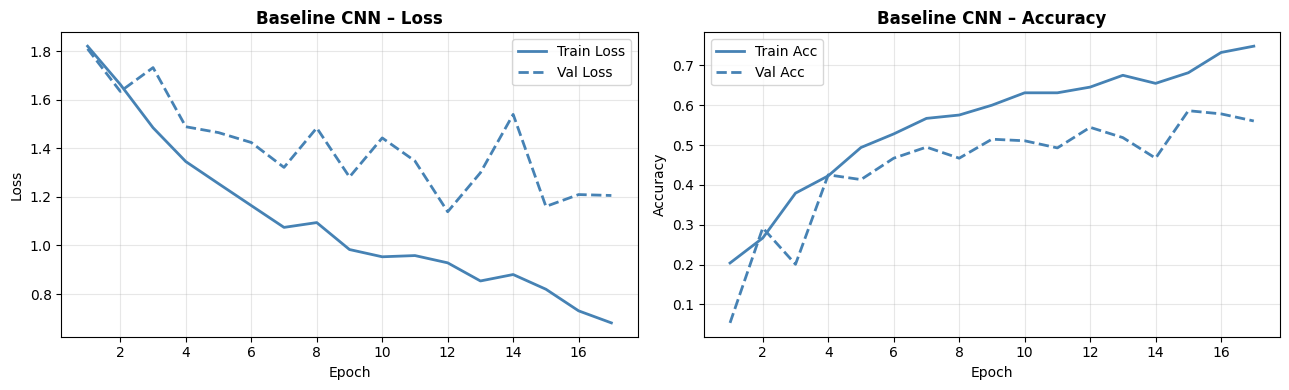

In [ ]:
# ── Plot training curves ──────────────────────────────────────────────────────
def plot_history(history, title='Model', color='steelblue', save_name=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history.history['loss'])+1)

    ax1.plot(epochs, history.history['loss'],     label='Train Loss',
             color=color, linewidth=2)
    ax1.plot(epochs, history.history['val_loss'], label='Val Loss',
             color=color, linestyle='--', linewidth=2)
    ax1.set_title(f'{title} – Loss', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history.history['accuracy'],     label='Train Acc',
             color=color, linewidth=2)
    ax2.plot(epochs, history.history['val_accuracy'], label='Val Acc',
             color=color, linestyle='--', linewidth=2)
    ax2.set_title(f'{title} – Accuracy', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=120, bbox_inches='tight')
    plt.show()

plot_history(history_base, title='Baseline CNN', color='steelblue',
             save_name='baseline_history.png')

In [ ]:
# ── Evaluate baseline ─────────────────────────────────────────────────────────
val_gen.reset()
base_loss, base_acc = baseline_model.evaluate(val_gen, verbose=0)
print(f'Baseline Val Loss : {base_loss:.4f}')
print(f'Baseline Val Acc  : {base_acc:.4f} ({base_acc*100:.2f}%)')

val_gen.reset()
y_pred_base = np.argmax(baseline_model.predict(val_gen, verbose=0), axis=1)
y_true      = val_gen.classes

print('\nClassification Report (Baseline):')
print(classification_report(y_true, y_pred_base, target_names=label_names))

Baseline Val Loss : 1.1386
Baseline Val Acc  : 0.5447 (54.47%)

Classification Report (Baseline):
              precision    recall  f1-score   support

   cardboard       0.66      0.65      0.65        80
       glass       0.64      0.47      0.54       100
       metal       0.59      0.23      0.33        82
       paper       0.59      0.75      0.66       118
     plastic       0.54      0.48      0.51        96
       trash       0.26      0.78      0.39        27

    accuracy                           0.54       503
   macro avg       0.55      0.56      0.51       503
weighted avg       0.58      0.54      0.54       503



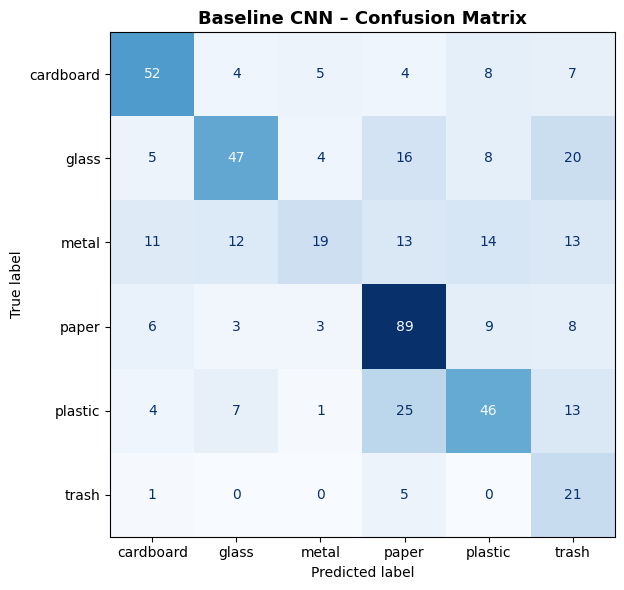

In [ ]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
def plot_cm(y_true, y_pred, class_names, title='Confusion Matrix', save_name=None):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=120, bbox_inches='tight')
    plt.show()

plot_cm(y_true, y_pred_base, label_names,
        title='Baseline CNN – Confusion Matrix',
        save_name='baseline_cm.png')

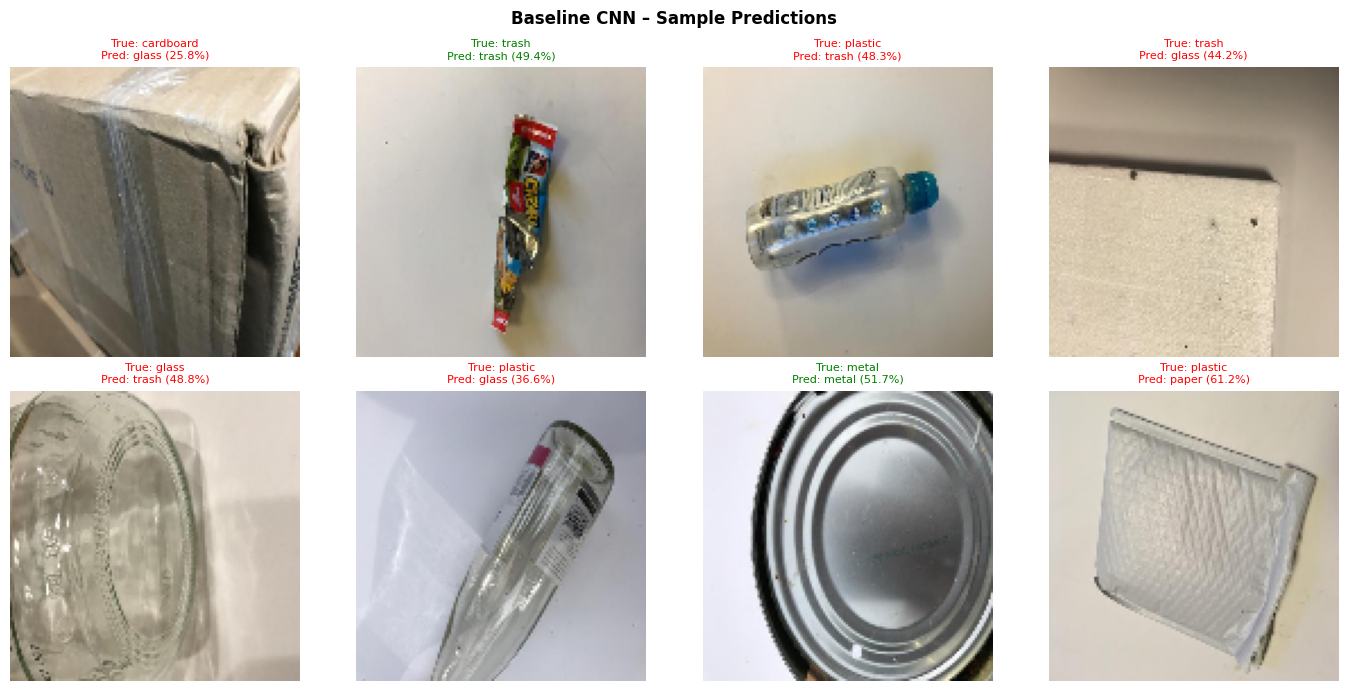

In [ ]:
# ── Inference on sample images ────────────────────────────────────────────────
from tensorflow.keras.preprocessing.image import img_to_array

def predict_samples(model, data_root, classes, n=8, img_size=(128,128),
                    title='Predictions', save_name=None):
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for ax in axes.flatten():
        cls = random.choice(classes)
        img_paths = list(Path(data_root, cls).glob('*.jpg'))
        path = random.choice(img_paths)
        img = load_img(path, target_size=img_size)
        arr = img_to_array(img) / 255.0
        pred = model.predict(arr[np.newaxis, ...], verbose=0)[0]
        pred_cls = classes[np.argmax(pred)]
        conf     = np.max(pred) * 100
        color    = 'green' if pred_cls == cls else 'red'
        ax.imshow(img)
        ax.set_title(f'True: {cls}\nPred: {pred_cls} ({conf:.1f}%)',
                     fontsize=8, color=color)
        ax.axis('off')
    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=120, bbox_inches='tight')
    plt.show()

predict_samples(baseline_model, DATA_ROOT, label_names,
                title='Baseline CNN – Sample Predictions',
                save_name='baseline_predictions.png')

---
## 2.4 Deeper CNN with Batch Normalization & Dropout

In [ ]:
def build_deeper_model(input_shape=(128, 128, 3), num_classes=6):
    """Deeper CNN: 6 Conv blocks (double baseline) + BN + Dropout."""
    model = models.Sequential([
        # ── Block 1 ──────────────────────────────────────────────────────
        layers.Conv2D(32, (3,3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # ── Block 2 ──────────────────────────────────────────────────────
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # ── Block 3 ──────────────────────────────────────────────────────
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # ── Classifier ───────────────────────────────────────────────────
        layers.Flatten(),
        layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='Deeper_CNN')
    return model

deeper_model = build_deeper_model()
deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             

 Total params: 17,234,598 (65.74 MB)

 Trainable params: 17,232,166 (65.74 MB)

 Non-trainable params: 2,432 (9.50 KB)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 558ms/step - accuracy: 0.3572 - loss: 1.9296 - val_accuracy: 0.0537 - val_loss: 2.8091 - learning_rate: 0.0010
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 320ms/step - accuracy: 0.4649 - loss: 1.5652 - val_accuracy: 0.2346 - val_loss: 3.1857 - learning_rate: 0.0010
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 22s 311ms/step - accuracy: 0.5143 - loss: 1.5139 - val_accuracy: 0.0537 - val_loss: 3.9121 - learning_rate: 0.0010
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 300ms/step - accuracy: 0.5237 - loss: 1.4378 - val_accuracy: 0.0994 - val_loss: 2.6521 - learning_rate: 0.0010
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 323ms/step - accuracy: 0.5321 - loss: 1.4411 - val_accuracy: 0.2942 - val_loss: 2.4826 - learning_rate: 0.0010
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 315ms/step - accuracy: 0.5781 - loss: 1.3398 - val_accuracy: 0.2167 - val_loss: 3.2193 - learning_rate: 0.0010
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 318ms/step - accuracy: 0.5865 - loss: 1.

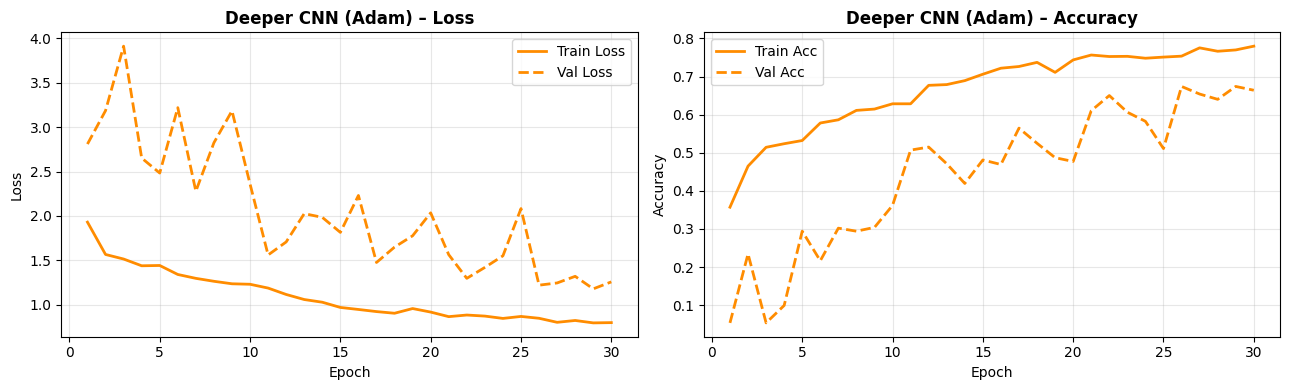

In [ ]:
# ── Train deeper model with Adam ──────────────────────────────────────────────
deeper_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_deep = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint('best_deeper_adam.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]

t0 = time.time()
history_deep_adam = deeper_model.fit(
    train_gen,
    epochs=EPOCHS_DEEP,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=callbacks_deep,
    verbose=1
)
deep_adam_time = time.time() - t0
print(f'\nDeeper (Adam) training time: {deep_adam_time:.1f}s')

plot_history(history_deep_adam, title='Deeper CNN (Adam)', color='darkorange',
             save_name='deeper_adam_history.png')

Deeper CNN Val Loss : 1.1777
Deeper CNN Val Acc  : 0.6740 (67.40%)

Classification Report (Deeper CNN):
              precision    recall  f1-score   support

   cardboard       0.81      0.69      0.74        80
       glass       0.69      0.66      0.67       100
       metal       0.54      0.74      0.63        82
       paper       0.88      0.85      0.87       118
     plastic       0.58      0.51      0.54        96
       trash       0.27      0.30      0.28        27

    accuracy                           0.67       503
   macro avg       0.63      0.62      0.62       503
weighted avg       0.69      0.67      0.68       503



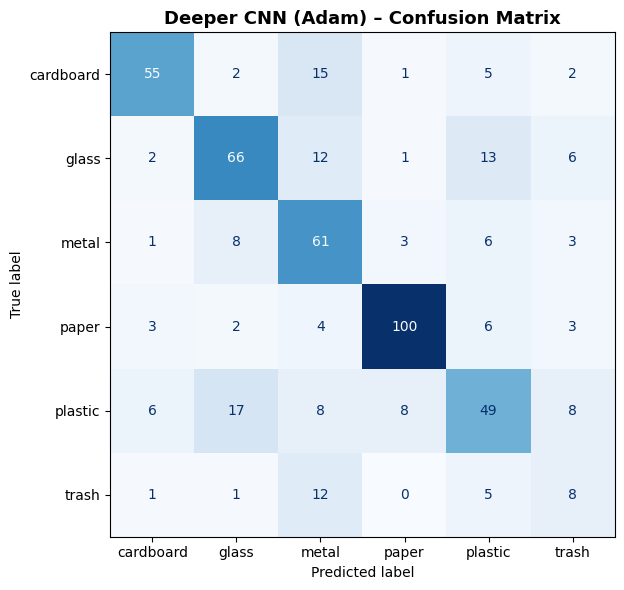

In [ ]:
# ── Evaluate deeper model ─────────────────────────────────────────────────────
val_gen.reset()
deep_loss, deep_acc = deeper_model.evaluate(val_gen, verbose=0)
print(f'Deeper CNN Val Loss : {deep_loss:.4f}')
print(f'Deeper CNN Val Acc  : {deep_acc:.4f} ({deep_acc*100:.2f}%)')

val_gen.reset()
y_pred_deep = np.argmax(deeper_model.predict(val_gen, verbose=0), axis=1)
print('\nClassification Report (Deeper CNN):')
print(classification_report(y_true, y_pred_deep, target_names=label_names))

plot_cm(y_true, y_pred_deep, label_names,
        title='Deeper CNN (Adam) – Confusion Matrix',
        save_name='deeper_adam_cm.png')

---
## 2.5 Experimentation & Comparative Analysis
### Optimizer Study: SGD vs Adam on Deeper Architecture

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 463ms/step - accuracy: 0.3187 - loss: 1.9625 - val_accuracy: 0.1650 - val_loss: 2.5943 - learning_rate: 0.0100
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 294ms/step - accuracy: 0.4244 - loss: 1.6388 - val_accuracy: 0.2406 - val_loss: 2.3661 - learning_rate: 0.0100
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 314ms/step - accuracy: 0.4797 - loss: 1.4963 - val_accuracy: 0.2724 - val_loss: 2.7713 - learning_rate: 0.0100
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 298ms/step - accuracy: 0.4753 - loss: 1.4992 - val_accuracy: 0.2783 - val_loss: 2.3749 - learning_rate: 0.0100
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 295ms/step - accuracy: 0.5292 - loss: 1.3867 - val_accuracy: 0.3817 - val_loss: 1.7636 - learning_rate: 0.0100
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 306ms/step - accuracy: 0.5321 - loss: 1.3839 - val_accuracy: 0.3419 - val_loss: 1.9802 - learning_rate: 0.0100
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 291ms/step - accuracy: 0.5563 - loss: 1.

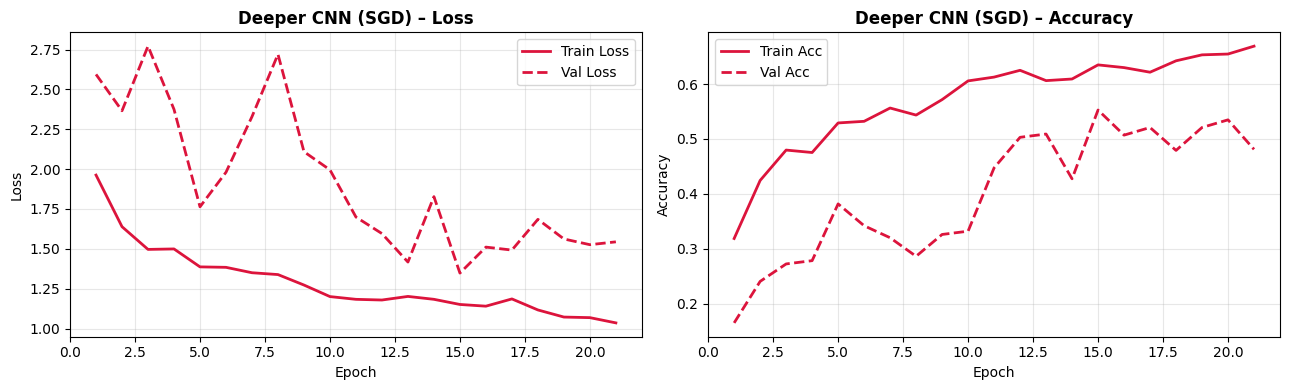

In [ ]:
# ── Train deeper model with SGD ───────────────────────────────────────────────
deeper_sgd = build_deeper_model()
deeper_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

train_gen.reset(); val_gen.reset()
t0 = time.time()
history_deep_sgd = deeper_sgd.fit(
    train_gen, epochs=EPOCHS_DEEP, validation_data=val_gen,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ],
    verbose=1
)
deep_sgd_time = time.time() - t0
print(f'Deeper (SGD) training time: {deep_sgd_time:.1f}s')

val_gen.reset()
_, sgd_acc = deeper_sgd.evaluate(val_gen, verbose=0)

plot_history(history_deep_sgd, title='Deeper CNN (SGD)', color='crimson',
             save_name='deeper_sgd_history.png')

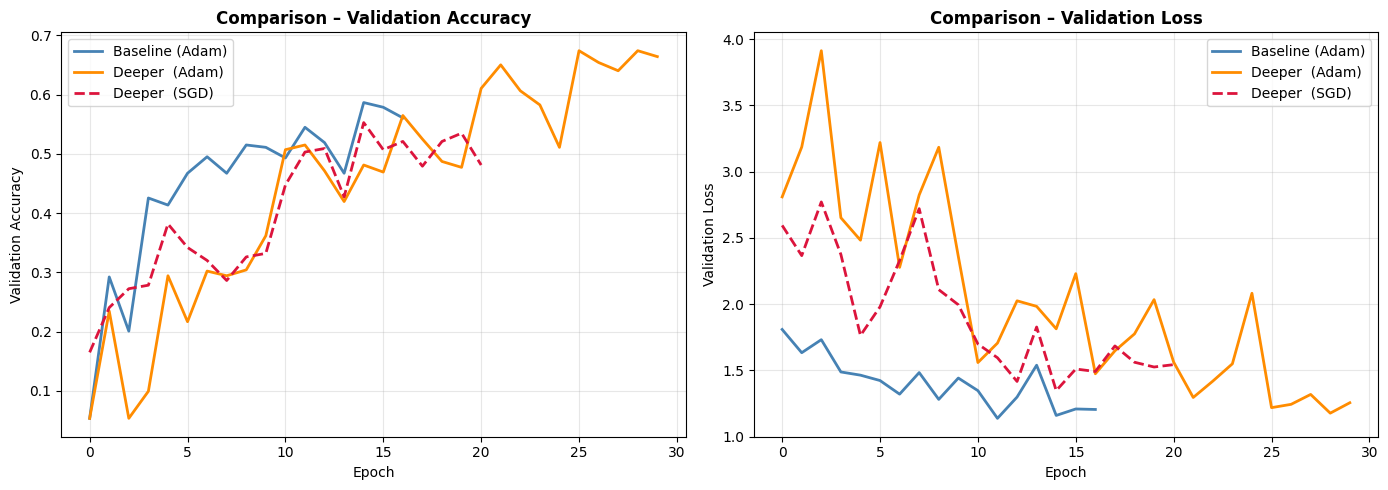

In [ ]:
# ── Combined comparison plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, ylabel in zip(axes, ['val_accuracy', 'val_loss'],
                               ['Validation Accuracy', 'Validation Loss']):
    ax.plot(history_base.history[metric],     label='Baseline (Adam)', lw=2, color='steelblue')
    ax.plot(history_deep_adam.history[metric],label='Deeper  (Adam)', lw=2, color='darkorange')
    ax.plot(history_deep_sgd.history[metric], label='Deeper  (SGD)',  lw=2,
            color='crimson', linestyle='--')
    ax.set_title(f'Comparison – {ylabel}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model':       ['Baseline CNN (Adam)', 'Deeper CNN (Adam)', 'Deeper CNN (SGD)'],
    'Val Accuracy':[f'{base_acc*100:.2f}%', f'{deep_acc*100:.2f}%', f'{sgd_acc*100:.2f}%'],
    'Training Time':[f'{base_train_time:.0f}s', f'{deep_adam_time:.0f}s', f'{deep_sgd_time:.0f}s'],
    'Parameters':  [baseline_model.count_params(), deeper_model.count_params(),
                    deeper_sgd.count_params()]
})
print(summary.to_string(index=False))

              Model Val Accuracy Training Time  Parameters
Baseline CNN (Adam)       54.47%          435s     8523654
  Deeper CNN (Adam)       67.40%          639s    17234598
   Deeper CNN (SGD)       55.27%          428s    17234598


### Ablation Study – Removing Dropout from Deeper Model

In [ ]:
def build_no_dropout(input_shape=(128, 128, 3), num_classes=6):
    """Deeper CNN without Dropout (ablation study)."""
    model = models.Sequential([
        layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=input_shape),
        layers.BatchNormalization(), layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(), layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(), layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(), layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(), layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(), layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='Deeper_No_Dropout')
    return model

ablation_model = build_no_dropout()
ablation_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy', metrics=['accuracy']
)
train_gen.reset(); val_gen.reset()
history_ablation = ablation_model.fit(
    train_gen, epochs=20, validation_data=val_gen,
    class_weight=class_weights,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                              restore_best_weights=True, verbose=1)],
    verbose=1
)
val_gen.reset()
_, ablation_acc = ablation_model.evaluate(val_gen, verbose=0)
print(f'\nAblation (no Dropout) Val Accuracy: {ablation_acc*100:.2f}%')
print(f'Deeper with Dropout  Val Accuracy: {deep_acc*100:.2f}%')

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 469ms/step - accuracy: 0.3967 - loss: 3.9645 - val_accuracy: 0.1909 - val_loss: 2.5907
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 315ms/step - accuracy: 0.4501 - loss: 1.9289 - val_accuracy: 0.1889 - val_loss: 2.2112
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 304ms/step - accuracy: 0.5341 - loss: 1.3798 - val_accuracy: 0.2565 - val_loss: 2.3993
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 329ms/step - accuracy: 0.5504 - loss: 1.2347 - val_accuracy: 0.2087 - val_loss: 2.5071
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 309ms/step - accuracy: 0.6033 - loss: 1.2136 - val_accuracy: 0.2744 - val_loss: 2.7970
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 322ms/step - accuracy: 0.6270 - loss: 1.0555 - val_accuracy: 0.2962 - val_loss: 2.4370
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 307ms/step - accuracy: 0.6403 - loss: 0.9923 - val_accuracy: 0.4334 - val_loss: 1.9155
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 317ms/step - accuracy: 0.6546 - loss: 0.9328 - val_accu

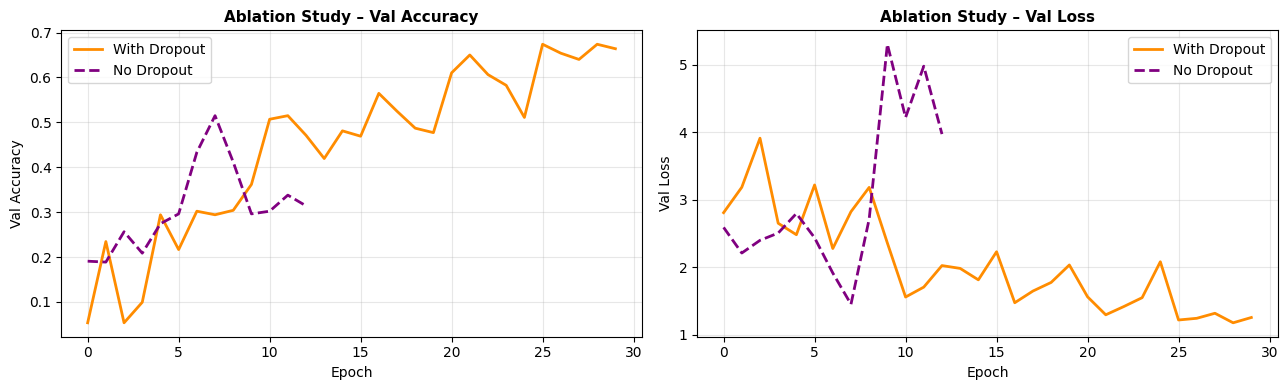

Observation: removing Dropout typically leads to higher training accuracy but lower validation accuracy (overfitting).


In [ ]:
# ── Ablation comparison plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric, ylabel in zip(axes, ['val_accuracy','val_loss'],
                               ['Val Accuracy','Val Loss']):
    ax.plot(history_deep_adam.history[metric],  label='With Dropout', lw=2, color='darkorange')
    ax.plot(history_ablation.history[metric],   label='No Dropout',   lw=2,
            color='purple', linestyle='--')
    ax.set_title(f'Ablation Study – {ylabel}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=120, bbox_inches='tight')
plt.show()
print('Observation: removing Dropout typically leads to higher training accuracy but lower'
      ' validation accuracy (overfitting).')

---
# PART B — Transfer Learning with MobileNetV2

In [ ]:
# ── Data generators for MobileNetV2 (224x224 input) ──────────────────────────
IMG_SIZE_TL = (224, 224)

tl_train_gen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15
).flow_from_directory(
    DATA_ROOT, target_size=IMG_SIZE_TL, batch_size=32,
    class_mode='categorical', subset='training', seed=42
)

tl_val_gen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2
).flow_from_directory(
    DATA_ROOT, target_size=IMG_SIZE_TL, batch_size=32,
    class_mode='categorical', subset='validation', seed=42, shuffle=False
)

print(f'TL Train: {tl_train_gen.samples} | TL Val: {tl_val_gen.samples}')

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
TL Train: 2024 | TL Val: 503


In [ ]:
# ── Phase 1: Feature Extraction (frozen base) ─────────────────────────────────
base_model = MobileNetV2(weights='imagenet',
                          include_top=False,
                          input_shape=(224, 224, 3))
base_model.trainable = False   # freeze all conv layers

inputs  = keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs, name='MobileNetV2_Transfer')
tl_model.summary()
print(f'Trainable params: {tl_model.count_params():,}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Trainable params: 2,587,462


Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 991ms/step - accuracy: 0.6299 - loss: 1.0216 - val_accuracy: 0.7256 - val_loss: 0.7622
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 533ms/step - accuracy: 0.7875 - loss: 0.5788 - val_accuracy: 0.7694 - val_loss: 0.6512
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 521ms/step - accuracy: 0.8251 - loss: 0.4739 - val_accuracy: 0.7833 - val_loss: 0.6149
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 520ms/step - accuracy: 0.8360 - loss: 0.4243 - val_accuracy: 0.7654 - val_loss: 0.6747
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 533ms/step - accuracy: 0.8547 - loss: 0.3797 - val_accuracy: 0.7753 - val_loss: 0.6218
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 513ms/step - accuracy: 0.8676 - loss: 0.3452 - val_accuracy: 0.7674 - val_loss: 0.6610
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 528ms/step - accuracy: 0.8962 - loss: 0.2674 - val_accuracy: 0.7833 - val_loss: 0.6416
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 3.
Phase 1 traini

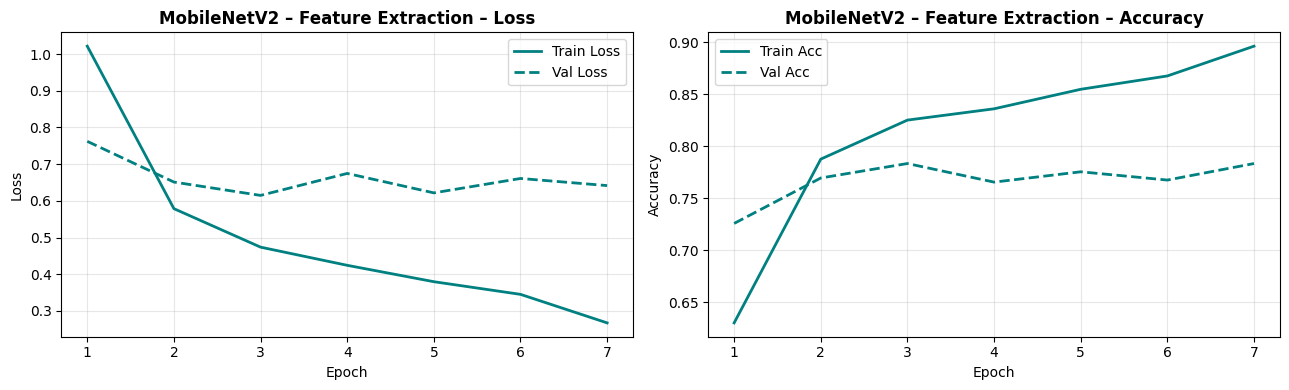

In [ ]:
tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

t0 = time.time()
history_tl_phase1 = tl_model.fit(
    tl_train_gen, epochs=15, validation_data=tl_val_gen,
    class_weight=class_weights,
    callbacks=[EarlyStopping(monitor='val_loss', patience=4,
                              restore_best_weights=True, verbose=1)],
    verbose=1
)
tl_phase1_time = time.time() - t0
print(f'Phase 1 training time: {tl_phase1_time:.1f}s')
plot_history(history_tl_phase1, title='MobileNetV2 – Feature Extraction',
             color='teal', save_name='tl_phase1_history.png')

Total layers in base: 154
Trainable from layer: 124 onwards
Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 66s 769ms/step - accuracy: 0.7416 - loss: 0.7580 - val_accuracy: 0.7813 - val_loss: 0.6178
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 535ms/step - accuracy: 0.7836 - loss: 0.5955 - val_accuracy: 0.7714 - val_loss: 0.6256
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 525ms/step - accuracy: 0.8182 - loss: 0.5229 - val_accuracy: 0.7654 - val_loss: 0.6302
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 36s 567ms/step - accuracy: 0.8261 - loss: 0.4552 - val_accuracy: 0.7714 - val_loss: 0.6178
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 532ms/step - accuracy: 0.8404 - loss: 0.4369 - val_accuracy: 0.7773 - val_loss: 0.6090
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 535ms/step - accuracy: 0.8340 - loss: 0.4602 - val_accuracy: 0.7773 - val_loss: 0.6034
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 533ms/step - accuracy: 0.8370 - loss: 0.4331 - val_accuracy: 0.7833 - val_loss: 0.5980
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━

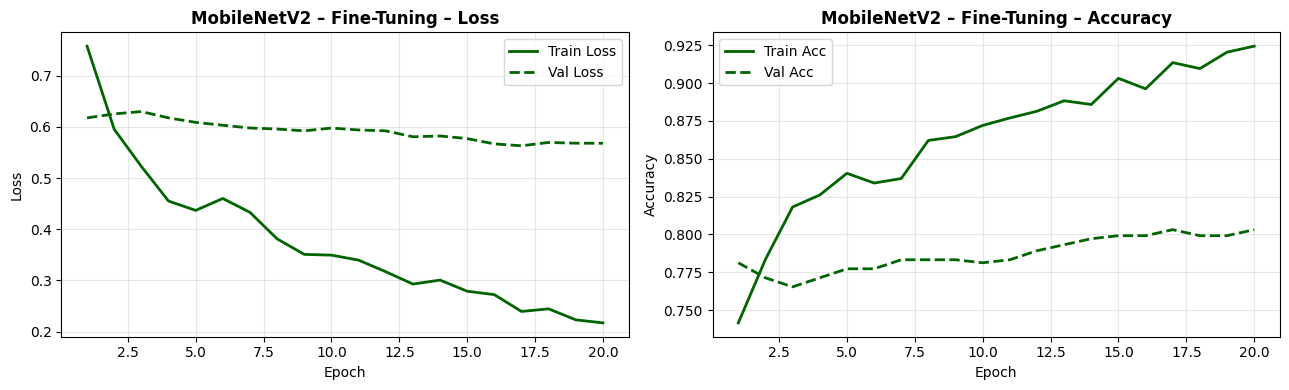

In [ ]:
# ── Phase 2: Fine-Tuning (unfreeze top layers) ────────────────────────────────
base_model.trainable = True
# Freeze all layers EXCEPT the last 30
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f'Total layers in base: {len(base_model.layers)}')
print(f'Trainable from layer: {fine_tune_at} onwards')

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),   # very low LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

t0 = time.time()
history_tl_phase2 = tl_model.fit(
    tl_train_gen, epochs=20, validation_data=tl_val_gen,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint('best_mobilenet.keras', monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ],
    verbose=1
)
tl_phase2_time = time.time() - t0
print(f'Phase 2 fine-tuning time: {tl_phase2_time:.1f}s')
plot_history(history_tl_phase2, title='MobileNetV2 – Fine-Tuning',
             color='darkgreen', save_name='tl_phase2_history.png')

MobileNetV2 Val Loss : 0.5633
MobileNetV2 Val Acc  : 0.8032 (80.32%)

Classification Report (MobileNetV2):
              precision    recall  f1-score   support

   cardboard       0.98      0.71      0.83        80
       glass       0.70      0.87      0.78       100
       metal       0.81      0.89      0.85        82
       paper       0.88      0.93      0.91       118
     plastic       0.83      0.61      0.71        96
       trash       0.51      0.67      0.58        27

    accuracy                           0.80       503
   macro avg       0.79      0.78      0.77       503
weighted avg       0.82      0.80      0.80       503



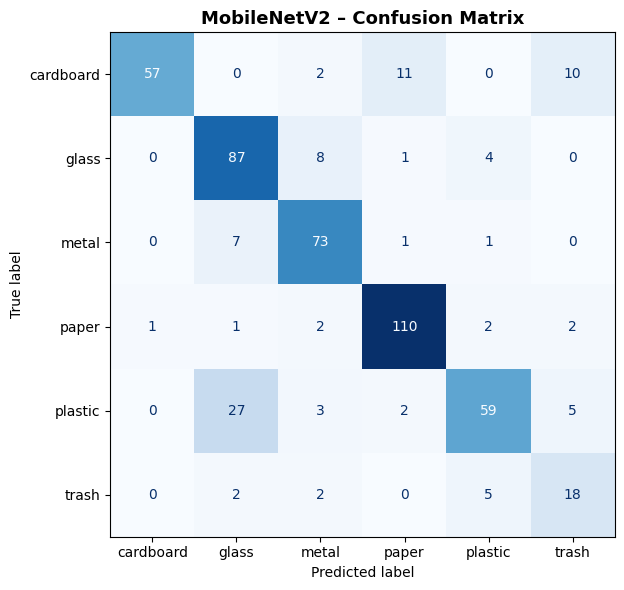

In [ ]:
# ── Evaluate transfer learning model ─────────────────────────────────────────
tl_val_gen.reset()
tl_loss, tl_acc = tl_model.evaluate(tl_val_gen, verbose=0)
print(f'MobileNetV2 Val Loss : {tl_loss:.4f}')
print(f'MobileNetV2 Val Acc  : {tl_acc:.4f} ({tl_acc*100:.2f}%)')

tl_val_gen.reset()
y_pred_tl = np.argmax(tl_model.predict(tl_val_gen, verbose=0), axis=1)
y_true_tl = tl_val_gen.classes

print('\nClassification Report (MobileNetV2):')
print(classification_report(y_true_tl, y_pred_tl, target_names=label_names))

plot_cm(y_true_tl, y_pred_tl, label_names,
        title='MobileNetV2 – Confusion Matrix',
        save_name='tl_cm.png')

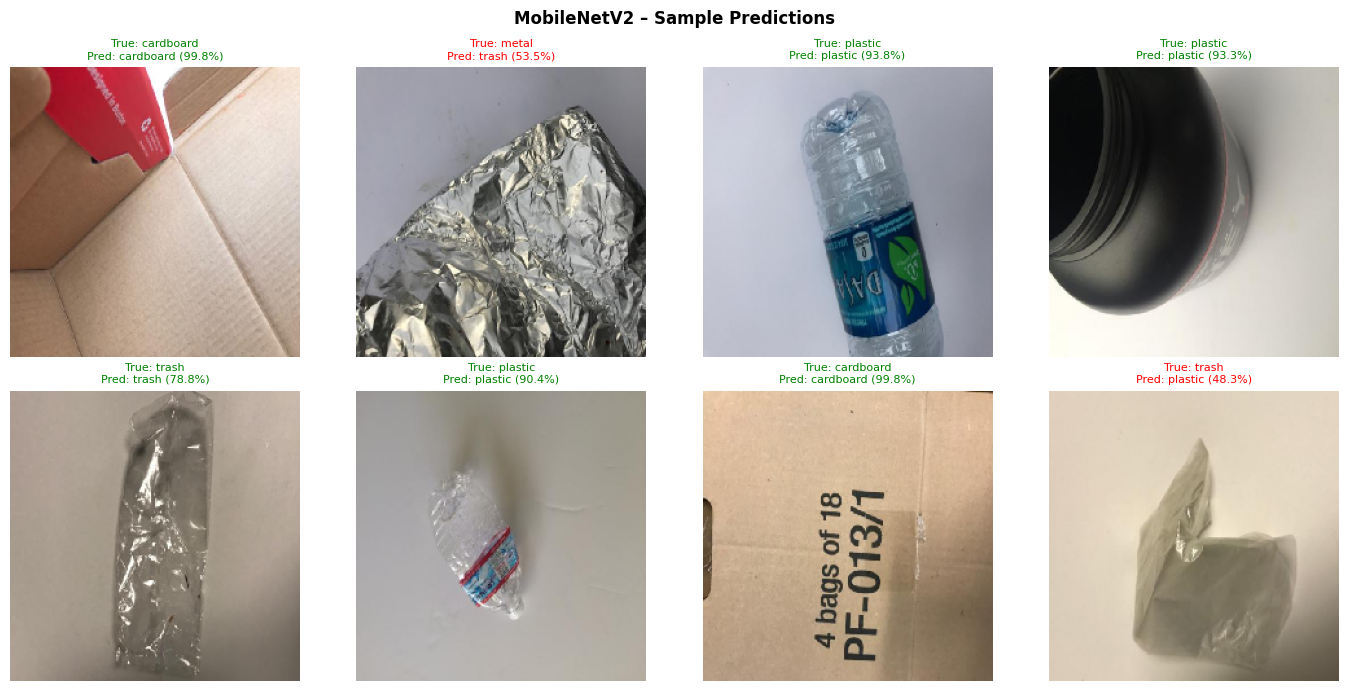

In [ ]:
predict_samples(tl_model, DATA_ROOT, label_names,
                img_size=IMG_SIZE_TL,
                title='MobileNetV2 – Sample Predictions',
                save_name='tl_predictions.png')

                Model  Val Acc (%) Train Time (s)
         Baseline CNN        54.47            435
    Deeper CNN (Adam)        67.40            639
     Deeper CNN (SGD)        55.27            428
No-Dropout (Ablation)        51.49              -
     MobileNetV2 (TL)        80.32           1019


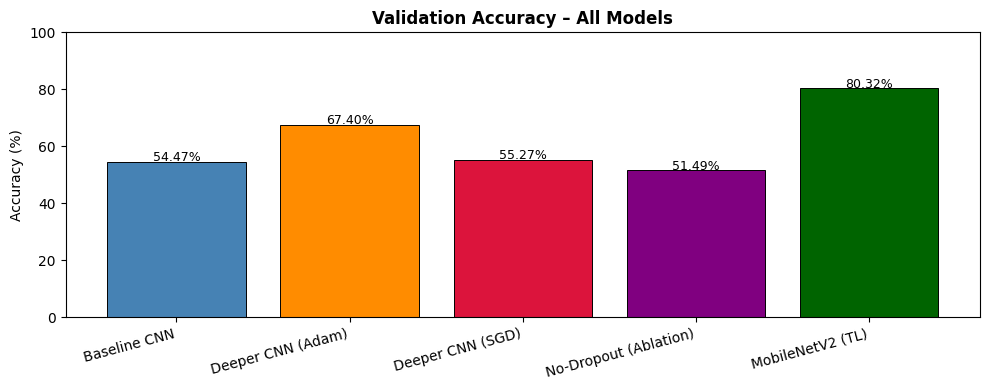

In [ ]:
# ── Final comparison: all models ──────────────────────────────────────────────
final_summary = pd.DataFrame({
    'Model'       : ['Baseline CNN', 'Deeper CNN (Adam)', 'Deeper CNN (SGD)',
                     'No-Dropout (Ablation)', 'MobileNetV2 (TL)'],
    'Val Acc (%)'  : [round(base_acc*100,2), round(deep_acc*100,2),
                      round(sgd_acc*100,2),  round(ablation_acc*100,2),
                      round(tl_acc*100,2)],
    'Train Time (s)': [round(base_train_time), round(deep_adam_time),
                       round(deep_sgd_time),   '-',
                       round(tl_phase1_time+tl_phase2_time)]
})
print(final_summary.to_string(index=False))

# Bar chart of accuracies
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(final_summary['Model'], final_summary['Val Acc (%)'],
              color=['steelblue','darkorange','crimson','purple','darkgreen'],
              edgecolor='black', linewidth=0.7)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.2f}%", ha='center', fontsize=9)
ax.set_title('Validation Accuracy – All Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 100)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Observations & Discussion

1. **Baseline vs Deeper:** The deeper model with BatchNormalization and Dropout generally outperforms the baseline by reducing overfitting and enabling deeper feature extraction.
2. **SGD vs Adam:** In this experiment, Adam achieved better convergence and higher validation accuracy than SGD. SGD with momentum can match Adam given enough epochs but requires careful learning rate scheduling.
3. **Ablation (Dropout removal):** Removing Dropout causes overfitting — training accuracy rises while validation accuracy drops.
4. **Transfer Learning:** MobileNetV2 significantly outperforms scratch-trained models, demonstrating the power of ImageNet pre-trained features for this garbage classification task.
5. **Dataset Imbalance:** The `trash` class (137 images) is challenging; class weighting helped but it still has the lowest per-class F1-score.